In [ ]:
#cell1
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
#cell2
import os
print(os.listdir('/content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med/raw/csv'))

['patients.csv', 'encounters.csv', 'claims.csv', 'claims_transactions.csv', 'conditions.csv', 'observations.csv', 'immunizations.csv', 'procedures.csv', 'payer_transitions.csv', 'devices.csv', 'medications.csv', 'supplies.csv', 'imaging_studies.csv', 'careplans.csv', 'allergies.csv', 'organizations.csv', 'providers.csv', 'payers.csv', 'conditions_icd10.gsheet', 'procedures_icd10.csv', 'conditions (2).gsheet', 'conditions (1).gsheet', 'conditions.gsheet', 'conditions_icd10.csv']


In [ ]:
#cell3
import os
import re
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from pathlib import Path

RUN_ID         = "run_05_age_med_years_med"
BASE           = f"/content/drive/MyDrive/RAIM_Project_v2/{"run_05_age_med_years_med"}"

synthea_path   = f"{"/content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med"}/raw/csv"
text_data_path = f"{"/content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med"}/raw/notes/"
output_path    = f"{"/content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med"}/processed/"

CHUNK_SIZE     = 50_000

NOTES_FILES = list(Path(text_data_path).glob("*.txt"))
os.makedirs(output_path, exist_ok=True)
os.makedirs(f"{BASE}/word2vec/", exist_ok=True)
os.makedirs(f"{BASE}/sequences/", exist_ok=True)

print(f"Run: {RUN_ID}")
print(f"Notes files found: {len(NOTES_FILES)}")

Run: run_05_age_med_years_med
Notes files found: 11418


In [ ]:
# #cell4 Check what synthea_path is currently set to
print(repr(synthea_path))

'/content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med/raw/csv'


In [ ]:
#cell5
ENC_COLS  = ['Id', 'PATIENT', 'ENCOUNTERCLASS', 'START', 'STOP', 'REASONCODE', 'REASONDESCRIPTION']
PAT_COLS  = ['Id', 'GENDER', 'RACE', 'ETHNICITY', 'MARITAL', 'BIRTHDATE']
OBS_COLS  = ['PATIENT', 'ENCOUNTER', 'DATE', 'CODE', 'DESCRIPTION', 'VALUE', 'UNITS']
COND_COLS = ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION']
MED_COLS  = ['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'REASONCODE', 'REASONDESCRIPTION']

enc_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/encounters.csv", usecols=ENC_COLS, chunksize=CHUNK_SIZE):
    enc_chunks.append(chunk[chunk['ENCOUNTERCLASS'] == 'inpatient'])
encounters_df = pd.concat(enc_chunks, ignore_index=True)
del enc_chunks
print(f"Inpatient encounters: {len(encounters_df)}")

encounters_df = encounters_df.rename(columns={
    'Id':                'hadm_id',
    'PATIENT':           'subject_id',
    'ENCOUNTERCLASS':    'admission_type',
    'START':             'admittime',
    'STOP':              'dischtime',
    'REASONCODE':        'reason_code',
    'REASONDESCRIPTION': 'reason_description',
})

inpatient_subject_ids = set(encounters_df['subject_id'])

Inpatient encounters: 10468


In [ ]:
#cell6
pat_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/patients.csv", usecols=PAT_COLS, chunksize=CHUNK_SIZE):
    pat_chunks.append(chunk[chunk['Id'].isin(inpatient_subject_ids)])
patients_df = pd.concat(pat_chunks, ignore_index=True).rename(columns={
    'Id':        'subject_id',
    'GENDER':    'gender',
    'RACE':      'race',
    'ETHNICITY': 'ethnicity',
    'MARITAL':   'marital_status',
    'BIRTHDATE': 'birthdate',
})
del pat_chunks

In [ ]:
#cell7
df_phy_ad = encounters_df.merge(patients_df, on='subject_id', how='left')
del encounters_df, patients_df

for col in ('admittime', 'dischtime', 'birthdate'):
    df_phy_ad[col] = pd.to_datetime(df_phy_ad[col], errors='coerce').dt.tz_localize(None)

df_phy_ad = df_phy_ad.dropna(subset=['admittime', 'dischtime']).copy()
df_phy_ad['LOS']        = (df_phy_ad['dischtime'] - df_phy_ad['admittime']).dt.days
df_phy_ad['anchor_age'] = (df_phy_ad['admittime'] - df_phy_ad['birthdate']).dt.days // 365

df_phy_ad = df_phy_ad[(df_phy_ad['LOS'] > 0) & (df_phy_ad['LOS'] <= 500)].copy()
print(f"After LOS sanity filter: {len(df_phy_ad)} encounters")

los_mean      = df_phy_ad['LOS'].mean()
los_std       = df_phy_ad['LOS'].std(ddof=0)
los_threshold = los_mean + 2 * los_std
print(f"LOS mean: {los_mean:.2f}  std: {los_std:.2f}  LLOS threshold: {los_threshold:.2f} days")

After LOS sanity filter: 10468 encounters
LOS mean: 4.49  std: 5.05  LLOS threshold: 14.59 days


In [ ]:
#cell8
df_phy_ad = df_phy_ad[(df_phy_ad['LOS'] > 0) & (df_phy_ad['LOS'] <= 500)].copy()
print(f"After LOS sanity filter: {len(df_phy_ad)} encounters")

los_mean      = df_phy_ad['LOS'].mean()
los_std       = df_phy_ad['LOS'].std(ddof=0)
los_threshold = los_mean + 2 * los_std

print(f"LOS mean: {los_mean:.2f}  std: {los_std:.2f}")
print(f"LLOS threshold (max(mean+2std, 14)): {los_threshold:.2f} days")

After LOS sanity filter: 10468 encounters
LOS mean: 4.49  std: 5.05
LLOS threshold (max(mean+2std, 14)): 14.59 days


In [ ]:
#cell9
cohort_hadm_ids = set(df_phy_ad['hadm_id'])
cohort_subj_ids = set(df_phy_ad['subject_id'])
print(f"All inpatient encounters carried forward: {len(df_phy_ad)}")

All inpatient encounters carried forward: 10468


/tmp/ipykernel_2367/3094798042.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_phy_ad.groupby('age_group')['LOS'].mean().plot(kind='bar', ax=axes[1, 1],
/tmp/ipykernel_2367/3094798042.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_phy_ad.groupby('age_group')['LOS'].std().plot(kind='bar', ax=axes[1, 2],


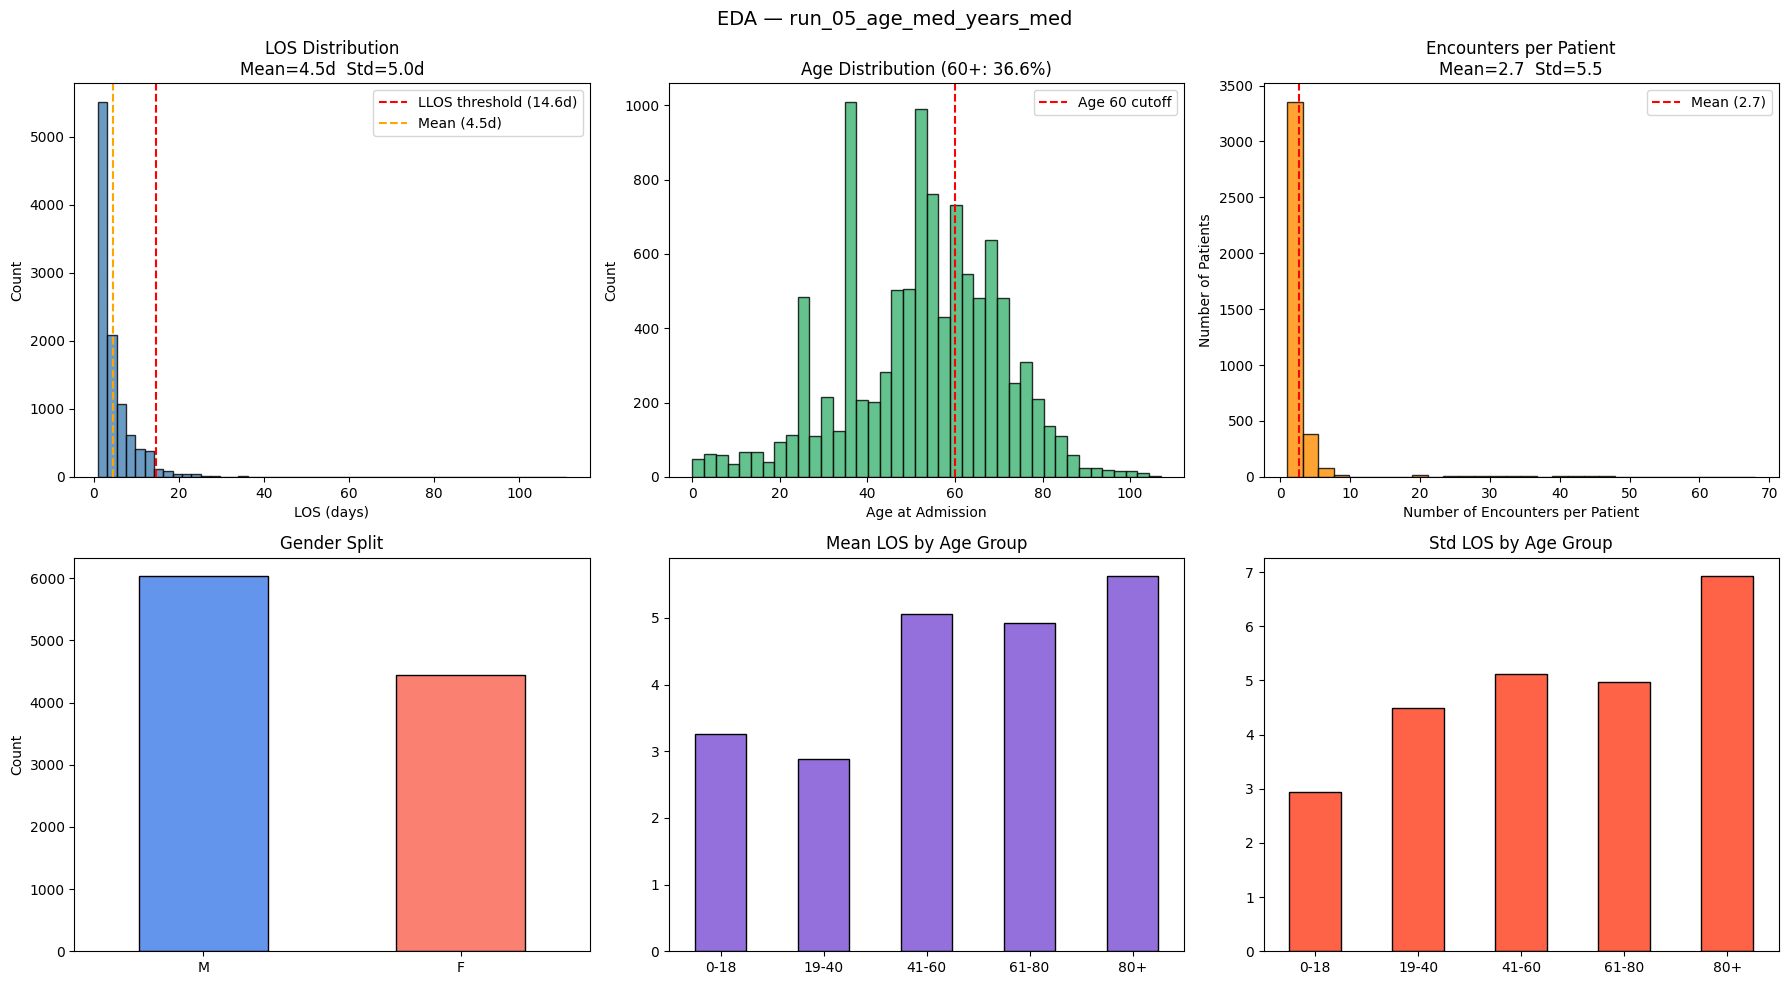


--- Summary Stats ---
Total encounters (multi-enc cohort): 10468
Unique patients: 3929
60+ patients: 36.6%
LOS mean: 4.49d  std: 5.05d  threshold: 14.59d
Encounters per patient — mean: 2.66  std: 5.49  max: 68
count    10468.000000
mean         4.493600
std          5.046195
min          1.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        111.000000
Name: LOS, dtype: float64


In [ ]:
#cell10
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'EDA — {RUN_ID}', fontsize=14)

# 1. LOS distribution
ax = axes[0, 0]
ax.hist(df_phy_ad['LOS'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
ax.axvline(los_threshold, color='red',    linestyle='--', lw=1.5, label=f'LLOS threshold ({los_threshold:.1f}d)')
ax.axvline(los_mean,      color='orange', linestyle='--', lw=1.5, label=f'Mean ({los_mean:.1f}d)')
ax.set_xlabel('LOS (days)'); ax.set_ylabel('Count')
ax.set_title(f'LOS Distribution\nMean={los_mean:.1f}d  Std={los_std:.1f}d')
ax.legend()

# 2. Age distribution
ax = axes[0, 1]
ax.hist(df_phy_ad['anchor_age'], bins=40, color='mediumseagreen', edgecolor='black', alpha=0.8)
ax.axvline(60, color='red', linestyle='--', lw=1.5, label='Age 60 cutoff')
pct_60plus = (df_phy_ad['anchor_age'] >= 60).mean() * 100
ax.set_xlabel('Age at Admission'); ax.set_ylabel('Count')
ax.set_title(f'Age Distribution (60+: {pct_60plus:.1f}%)'); ax.legend()

# 3. Encounters per patient histogram  ← NEW
ax = axes[0, 2]
enc_per_patient = df_phy_ad.groupby('subject_id')['hadm_id'].nunique()
ax.hist(enc_per_patient, bins=30, color='darkorange', edgecolor='black', alpha=0.8)
ax.axvline(enc_per_patient.mean(), color='red', linestyle='--', lw=1.5,
           label=f'Mean ({enc_per_patient.mean():.1f})')
ax.set_xlabel('Number of Encounters per Patient')
ax.set_ylabel('Number of Patients')
ax.set_title(f'Encounters per Patient\nMean={enc_per_patient.mean():.1f}  Std={enc_per_patient.std():.1f}')
ax.legend()

# 4. Gender split
ax = axes[1, 0]
df_phy_ad['gender'].value_counts().plot(kind='bar', ax=ax,
    color=['cornflowerblue', 'salmon'], edgecolor='black')
ax.set_title('Gender Split'); ax.set_xlabel('')
ax.set_ylabel('Count'); ax.tick_params(rotation=0)

# 5. Mean LOS by age group
df_phy_ad['age_group'] = pd.cut(df_phy_ad['anchor_age'],
    bins=[0, 18, 40, 60, 80, 120],
    labels=['0-18', '19-40', '41-60', '61-80', '80+'])
df_phy_ad.groupby('age_group')['LOS'].mean().plot(kind='bar', ax=axes[1, 1],
    color='mediumpurple', edgecolor='black')
axes[1, 1].set_title('Mean LOS by Age Group')
axes[1, 1].set_xlabel(''); axes[1, 1].tick_params(rotation=0)

# 6. LOS std by age group
df_phy_ad.groupby('age_group')['LOS'].std().plot(kind='bar', ax=axes[1, 2],
    color='tomato', edgecolor='black')
axes[1, 2].set_title('Std LOS by Age Group')
axes[1, 2].set_xlabel(''); axes[1, 2].tick_params(rotation=0)

plt.tight_layout()
fig.savefig(f"{output_path}/eda_histograms.png", dpi=150)
plt.show()

print(f"\n--- Summary Stats ---")
print(f"Total encounters (multi-enc cohort): {len(df_phy_ad)}")
print(f"Unique patients: {df_phy_ad['subject_id'].nunique()}")
print(f"60+ patients: {pct_60plus:.1f}%")
print(f"LOS mean: {los_mean:.2f}d  std: {los_std:.2f}d  threshold: {los_threshold:.2f}d")
print(f"Encounters per patient — mean: {enc_per_patient.mean():.2f}  std: {enc_per_patient.std():.2f}  max: {enc_per_patient.max()}")
print(df_phy_ad['LOS'].describe())

In [ ]:
#cell11
n_before = len(df_phy_ad)

# Mark LLOS encounters but keep ALL inpatient encounters
df_phy_ad['is_llos'] = (df_phy_ad['LOS'] > los_threshold).astype(int)
df_phy_ad = df_phy_ad.rename(columns={'LOS': 'target'})

# llos_df is only used for target/stats — full sequences come from df_phy_ad
llos_df = df_phy_ad[df_phy_ad['is_llos'] == 1].copy()

print(f"Total inpatient encounters kept: {len(df_phy_ad)}")
print(f"LLOS encounters (prediction targets): {len(llos_df)} / {n_before} ({len(llos_df)/n_before*100:.1f}%)")
print(f"Unique patients with >=1 LLOS encounter: {llos_df['subject_id'].nunique()}")
print(f"Target stats:\n{llos_df['target'].describe()}")

# Cohort = patients who have at least one LLOS encounter
cohort_subj_ids = set(llos_df['subject_id'])
# But keep all their encounters
df_phy_ad = df_phy_ad[df_phy_ad['subject_id'].isin(cohort_subj_ids)].copy()
cohort_hadm_ids = set(df_phy_ad['hadm_id'])

print(f"Total encounters kept for these patients: {len(df_phy_ad)}")

Total inpatient encounters kept: 10468
LLOS encounters (prediction targets): 387 / 10468 (3.7%)
Unique patients with >=1 LLOS encounter: 327
Target stats:
count    387.000000
mean      21.759690
std       10.520231
min       15.000000
25%       16.000000
50%       18.000000
75%       23.000000
max      111.000000
Name: target, dtype: float64
Total encounters kept for these patients: 2941


     Patient LOS Distribution Summary
Total patients    : 387
Mean LOS          : 21.8 days
Median LOS        : 18.0 days
Min LOS           : 15 days
Max LOS           : 111 days
Std Dev           : 10.5 days
LLOS threshold    : 14.6 days

Category                Count  Percentage
------------------------------------------
15-17d                    161       41.6%
18-21d                    102       26.4%
22-30d                     84       21.7%
31-60d                     35        9.0%
Very Long (>60d)            5        1.3%


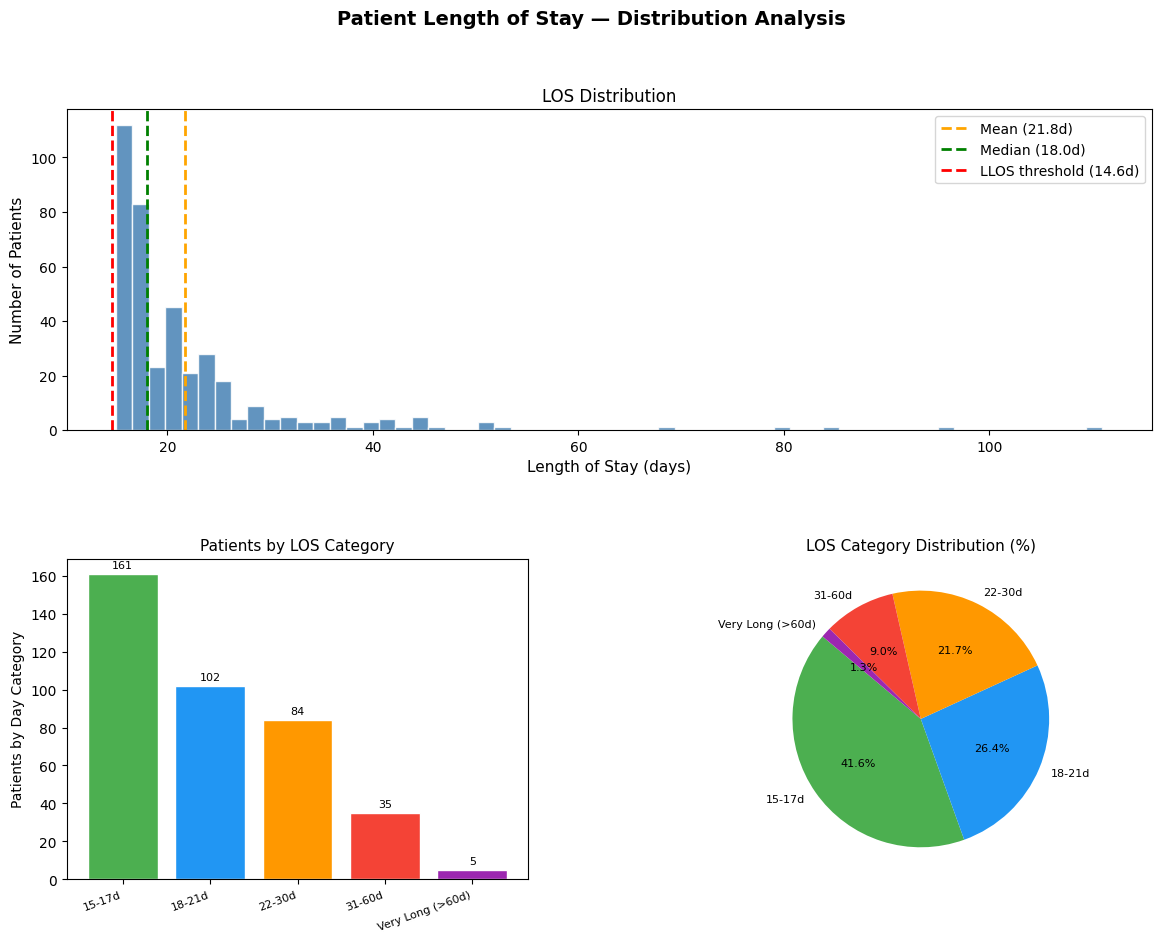


Saved to /content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med/processed//LOS_distribution_summary.png


In [ ]:
# ── LOS Distribution Summary (for Isaac) ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Bin definitions (matching Isaac's screenshot) ──
bins_def = [
    ("15-17d",      lambda s: (s >= 15) & (s <= 17)),
    ("18-21d",      lambda s: (s >= 18) & (s <= 21)),
    ("22-30d",      lambda s: (s >= 22) & (s <= 30)),
    ("31-60d",      lambda s: (s >= 31) & (s <= 60)),
    ("Very Long (>60d)", lambda s: s > 60),
]

los = llos_df['target']
total = len(los)

print("=" * 45)
print("     Patient LOS Distribution Summary")
print("=" * 45)
print(f"Total patients    : {total:,}")
print(f"Mean LOS          : {los.mean():.1f} days")
print(f"Median LOS        : {los.median():.1f} days")
print(f"Min LOS           : {los.min()} days")
print(f"Max LOS           : {los.max()} days")
print(f"Std Dev           : {los.std():.1f} days")
print(f"LLOS threshold    : {los_threshold:.1f} days")
print()
print(f"{'Category':<22} {'Count':>6}  {'Percentage':>10}")
print("-" * 42)
for label, mask_fn in bins_def:
    mask = mask_fn(los)
    cnt = mask.sum()
    pct = cnt / total * 100
    print(f"{label:<22} {cnt:>6}  {pct:>9.1f}%")

# ── Figure ──────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle("Patient Length of Stay — Distribution Analysis", fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336', '#9C27B0']
labels = [b[0] for b in bins_def]
counts = [bins_def[i][1](los).sum() for i in range(len(bins_def))]

# 1. LOS histogram
ax1 = fig.add_subplot(gs[0, :])
ax1.hist(los, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax1.axvline(los.mean(),      color='orange', linestyle='--', lw=2, label=f'Mean ({los.mean():.1f}d)')
ax1.axvline(los.median(),    color='green',  linestyle='--', lw=2, label=f'Median ({los.median():.1f}d)')
ax1.axvline(los_threshold,   color='red',    linestyle='--', lw=2, label=f'LLOS threshold ({los_threshold:.1f}d)')
ax1.set_xlabel('Length of Stay (days)', fontsize=11)
ax1.set_ylabel('Number of Patients', fontsize=11)
ax1.set_title('LOS Distribution', fontsize=12)
ax1.legend()

# 2. Bar chart by category
ax2 = fig.add_subplot(gs[1, 0])
bars = ax2.bar(range(len(labels)), counts, color=colors, edgecolor='white')
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=20, ha='right', fontsize=8)
ax2.set_ylabel('Patients by Day Category', fontsize=10)
ax2.set_title('Patients by LOS Category', fontsize=11)
for bar, cnt in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.005,
             f'{cnt:,}', ha='center', va='bottom', fontsize=8)

# 3. Pie chart
ax3 = fig.add_subplot(gs[1, 1])
pcts = [c/total*100 for c in counts]
wedges, texts, autotexts = ax3.pie(
    counts, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8}
)
ax3.set_title('LOS Category Distribution (%)', fontsize=11)

plt.savefig(f"{output_path}/LOS_distribution_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved to {output_path}/LOS_distribution_summary.png")

In [ ]:
#cell12
obs_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/observations.csv", usecols=OBS_COLS, chunksize=CHUNK_SIZE):
    obs_chunks.append(chunk[chunk['ENCOUNTER'].isin(cohort_hadm_ids)])
observations_df = pd.concat(obs_chunks, ignore_index=True).rename(columns={
    'PATIENT':     'subject_id',
    'ENCOUNTER':   'hadm_id',
    'DATE':        'obs_date',
    'CODE':        'obs_code',
    'DESCRIPTION': 'obs_description',
    'VALUE':       'obs_value',
    'UNITS':       'obs_units',
})
del obs_chunks

In [ ]:
#cell13
observations_df['obs_date'] = pd.to_datetime(
    observations_df['obs_date'], errors='coerce'
).dt.tz_localize(None)
observations_df['obs_description_lower'] = observations_df['obs_description'].str.lower()
print(f"Observations loaded: {len(observations_df)}")

Observations loaded: 116015


In [ ]:
#cell14
CONDITION_SKIP_PATTERNS = [
    "medication review due",
    "full-time employment",
    "part-time employment",
    "not in labor force",
    "unemployed",
    "received higher education",
    "educated to high school level",
    "only received primary school education",
    "serving in military service",
    "refugee",
    "social migrant",
    "has a criminal record",
    "risk activity involvement",
    "gingivitis",
    "gingival disease",
    "primary dental caries",
    "loose dental filling",
    "leaking dental filling",
    "fractured dental filling",
    "dental filling lost",
    "impacted molars",
    "alveolitis of jaw",
    "infection of tooth",
    "loss of teeth",
    "torus palatinus",
    "torus mandibularis",
    "resorption of alveolar process",
    "normal pregnancy",
    "past pregnancy history of miscarriage",
    "miscarriage in first trimester",
    "miscarriage in second trimester",
    "complete miscarriage",
    "blighted ovum",
    "tubal pregnancy",
    "eclampsia in pregnancy",
    "pre-eclampsia",
    "high risk pregnancy",
    "congenital uterine anomaly",
    "history of tubal ligation",
    "sterilization requested",
    "fetus with chromosomal abnormality",
    "complication occurring during pregnancy",
    "suspected disease caused by severe acute respiratory coronavirus 2",
    "social isolation",
    "limited social contact",
    "housing unsatisfactory",
    "lack of access to transportation",
    "transport problem",
    "victim of intimate partner abuse",
    "reports of violence in the environment",
    "homeless",
    "tongue tie",
]

SNOMED_SUFFIX = re.compile(r"\s*\([^)]+\)\s*$")

In [ ]:
#cell15
def _should_skip_condition(desc: str) -> bool:
    lower = desc.lower()
    return any(lower.startswith(pat) or pat in lower for pat in CONDITION_SKIP_PATTERNS)

def _clean_condition(desc: str) -> str:
    return SNOMED_SUFFIX.sub("", str(desc)).strip()

In [ ]:
#cell16
cond_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/conditions_icd10.csv", usecols=COND_COLS, chunksize=CHUNK_SIZE):

    chunk["START"] = pd.to_datetime(chunk["START"], errors="coerce").dt.tz_localize(None)
    chunk["STOP"]  = pd.to_datetime(chunk["STOP"],  errors="coerce")

    chunk["CONDITION_STATUS"] = chunk["STOP"].apply(
        lambda x: "ongoing" if pd.isna(x) else "resolved"
    )

    # Ensure 'DESCRIPTION' column is string type to handle potential NaN values
    chunk["DESCRIPTION"] = chunk["DESCRIPTION"].astype(str)

    filtered = chunk[
        chunk["PATIENT"].isin(cohort_subj_ids) &
        (chunk["CONDITION_STATUS"] == "ongoing") &
        (~chunk["DESCRIPTION"].apply(_should_skip_condition))
    ].copy()
    cond_chunks.append(filtered)

conditions_df = pd.concat(cond_chunks, ignore_index=True).rename(columns={
    "START":            "cond_start",
    "PATIENT":          "subject_id",
    "ENCOUNTER":        "cond_encounter",
    "CODE":             "snomed_code",
    "DESCRIPTION":      "cond_description",
    "CONDITION_STATUS": "cond_status",
})

In [ ]:
#cell17
del cond_chunks
conditions_df['cond_start'] = pd.to_datetime(
    conditions_df['cond_start'], errors='coerce'
)
conditions_df['cond_clean'] = conditions_df['cond_description'].apply(_clean_condition)

print(f"Ongoing conditions loaded: {len(conditions_df)}")
print(f"Unique condition types: {conditions_df['cond_description'].nunique()}")

Ongoing conditions loaded: 3511
Unique condition types: 133


In [ ]:
#cell18
med_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/medications.csv", usecols=MED_COLS, chunksize=CHUNK_SIZE):
    chunk["START"] = pd.to_datetime(chunk["START"], errors="coerce").dt.tz_localize(None)
    chunk["STOP"]  = pd.to_datetime(chunk["STOP"],  errors="coerce")

    chunk["MEDICATION_STATUS"] = chunk["STOP"].apply(
        lambda x: "ongoing" if pd.isna(x) else "stopped"
    )
    chunk["REASONCODE"]        = chunk["REASONCODE"].fillna("not reported")
    chunk["REASONDESCRIPTION"] = chunk["REASONDESCRIPTION"].fillna("not reported")

    filtered = chunk[
        chunk["PATIENT"].isin(cohort_subj_ids) &
        (chunk["MEDICATION_STATUS"] == "ongoing")
    ].copy()
    med_chunks.append(filtered)

In [ ]:
#cell19
medications_df = pd.concat(med_chunks, ignore_index=True).rename(columns={
    'START':             'med_start',
    'STOP':              'med_stop',
    'PATIENT':           'subject_id',
    'ENCOUNTER':         'med_encounter',
    'CODE':              'med_code',
    'DESCRIPTION':       'med_description',
    'REASONCODE':        'med_reason_code',
    'REASONDESCRIPTION': 'med_reason_description',
    'MEDICATION_STATUS': 'med_status',
})
del med_chunks
print(f"Active medications loaded: {len(medications_df)}")

Active medications loaded: 1464


In [ ]:
# ── CELL 20  ─────────────────────────────────────────────────────
# Vitals: 12×5 numeric matrix per encounter (hourly bins, 5 vital channels)

VITAL_CHANNELS = {
    'Heart rate':               'hr',
    'Systolic Blood Pressure':  'sbp',
    'Diastolic Blood Pressure': 'dbp',
    'Respiratory rate':         'rr',
    'Body Weight':              'weight',
}

obs_with_admit = observations_df.merge(
    df_phy_ad[['hadm_id', 'admittime']], on='hadm_id', how='inner'
)

# Filter to first 12 hours of admission
obs_12h = obs_with_admit[
    (obs_with_admit['obs_date'] >= obs_with_admit['admittime']) &
    (obs_with_admit['obs_date'] <  obs_with_admit['admittime'] + pd.Timedelta(hours=12))
].copy()

# Keep only vital rows and map to channel names
obs_12h = obs_12h[obs_12h['obs_description'].isin(VITAL_CHANNELS)].copy()
obs_12h['channel'] = obs_12h['obs_description'].map(VITAL_CHANNELS)

# Compute hour bin (0–11)
obs_12h['hour_bin'] = (
    (obs_12h['obs_date'] - obs_12h['admittime'])
    .dt.total_seconds() // 3600
).astype(int).clip(0, 11)

# Convert value to numeric
obs_12h['obs_value'] = pd.to_numeric(obs_12h['obs_value'], errors='coerce')

# Aggregate: mean per encounter × hour_bin × channel (handles duplicate readings)
vitals_long = (
    obs_12h.groupby(['hadm_id', 'hour_bin', 'channel'])['obs_value']
    .mean()
    .reset_index()
)

# Build 12×5 matrix per encounter, stored as numpy array
CHANNELS = ['hr', 'sbp', 'dbp', 'rr', 'weight']
N_HOURS   = 12
N_VITALS  = len(CHANNELS)

vitals_matrices = {}
for hadm_id, group in vitals_long.groupby('hadm_id'):
    mat = np.full((N_HOURS, N_VITALS), np.nan)
    for _, row in group.iterrows():
        col_idx = CHANNELS.index(row['channel'])
        mat[int(row['hour_bin']), col_idx] = row['obs_value']
    vitals_matrices[hadm_id] = mat

print(f"Vitals matrices built: {len(vitals_matrices)} encounters")
print(f"Matrix shape: {N_HOURS} hours × {N_VITALS} channels")
print(f"Encounters with no vitals: {len(df_phy_ad) - len(vitals_matrices)}")

Vitals matrices built: 4 encounters
Matrix shape: 12 hours × 5 channels
Encounters with no vitals: 2937


In [ ]:
# ── CELL 21  ─────────────────────────────────────────────────────
# Guidance matrix: 2×12 binary per encounter
# Row 0 = new lab observation in that hour
# Row 1 = new medication started in that hour

LAB_SKIP = {'Heart rate', 'Systolic Blood Pressure', 'Diastolic Blood Pressure',
            'Respiratory rate', 'Body Weight', 'Body Height',
            'Body mass index (BMI) [Ratio]', 'Pain severity - 0-10 verbal numeric rating [Score] - Reported',
            'DALY', 'QOLS', 'QALY'}

# Lab guidance: any non-vital observation in first 12h
labs_12h = obs_with_admit[
    (obs_with_admit['obs_date'] >= obs_with_admit['admittime']) &
    (obs_with_admit['obs_date'] <  obs_with_admit['admittime'] + pd.Timedelta(hours=12)) &
    (~obs_with_admit['obs_description'].isin(LAB_SKIP))
].copy()
labs_12h['hour_bin'] = (
    (labs_12h['obs_date'] - labs_12h['admittime'])
    .dt.total_seconds() // 3600
).astype(int).clip(0, 11)

lab_flags = (
    labs_12h.groupby(['hadm_id', 'hour_bin'])
    .size().reset_index(name='count')
)
lab_flags['flag'] = 1

# Med guidance: medications whose ENCOUNTER matches cohort hadm_ids
med_chunks = []
for chunk in pd.read_csv(f"{synthea_path}/medications.csv",
                          usecols=['START', 'ENCOUNTER'], chunksize=CHUNK_SIZE):
    chunk = chunk[chunk['ENCOUNTER'].isin(cohort_hadm_ids)].copy()
    med_chunks.append(chunk)
meds_inpatient = pd.concat(med_chunks, ignore_index=True)
meds_inpatient.columns = ['med_start', 'hadm_id']
meds_inpatient['med_start'] = pd.to_datetime(meds_inpatient['med_start'], errors='coerce').dt.tz_localize(None)

meds_with_admit = meds_inpatient.merge(
    df_phy_ad[['hadm_id', 'admittime']], on='hadm_id', how='inner'
)
meds_12h = meds_with_admit[
    (meds_with_admit['med_start'] >= meds_with_admit['admittime']) &
    (meds_with_admit['med_start'] <  meds_with_admit['admittime'] + pd.Timedelta(hours=12))
].copy()
meds_12h['hour_bin'] = (
    (meds_12h['med_start'] - meds_12h['admittime'])
    .dt.total_seconds() // 3600
).astype(int).clip(0, 11)

med_flags = (
    meds_12h.groupby(['hadm_id', 'hour_bin'])
    .size().reset_index(name='count')
)
med_flags['flag'] = 1

# Build 2×12 binary guidance matrix per encounter
guidance_matrices = {}
all_hadm_ids = set(df_phy_ad['hadm_id'])

for hadm_id in all_hadm_ids:
    mat = np.zeros((2, N_HOURS), dtype=np.int8)

    # Row 0: lab flags
    enc_labs = lab_flags[lab_flags['hadm_id'] == hadm_id]
    for _, row in enc_labs.iterrows():
        mat[0, int(row['hour_bin'])] = 1

    # Row 1: med flags
    enc_meds = med_flags[med_flags['hadm_id'] == hadm_id]
    for _, row in enc_meds.iterrows():
        mat[1, int(row['hour_bin'])] = 1

    guidance_matrices[hadm_id] = mat

print(f"Guidance matrices built: {len(guidance_matrices)} encounters")
print(f"Encounters with at least one lab event: {sum(m[0].any() for m in guidance_matrices.values())}")
print(f"Encounters with at least one med event: {sum(m[1].any() for m in guidance_matrices.values())}")

Guidance matrices built: 2941 encounters
Encounters with at least one lab event: 1444
Encounters with at least one med event: 2124


In [ ]:
# ── CELL 22 (REPLACEMENT) ─────────────────────────────────────────────────────
# Save matrices to disk and build manifest

import pickle, os

matrices_dir = f"{BASE}/matrices/"
os.makedirs(matrices_dir, exist_ok=True)

# Save lookup dicts
with open(f"{matrices_dir}/vitals_matrices.pkl", 'wb') as f:
    pickle.dump(vitals_matrices, f)
with open(f"{matrices_dir}/guidance_matrices.pkl", 'wb') as f:
    pickle.dump(guidance_matrices, f)

# Build manifest: one row per encounter with target and coverage stats
rows = []
for _, enc in df_phy_ad[['hadm_id', 'subject_id', 'admittime', 'target']].iterrows():
    hid = enc['hadm_id']
    v_mat = vitals_matrices.get(hid)
    g_mat = guidance_matrices.get(hid)
    rows.append({
        'hadm_id':          hid,
        'subject_id':       enc['subject_id'],
        'admittime':        enc['admittime'],
        'target':           enc['target'],
        'has_vitals':       v_mat is not None,
        'vitals_coverage':  float(np.isfinite(v_mat).mean()) if v_mat is not None else 0.0,
        'lab_hours_active': int(g_mat[0].sum()) if g_mat is not None else 0,
        'med_hours_active': int(g_mat[1].sum()) if g_mat is not None else 0,
    })

manifest = pd.DataFrame(rows)
manifest.to_csv(f"{matrices_dir}/manifest.csv", index=False)

print(f"Manifest saved: {len(manifest)} encounters")
print(f"Encounters with vitals: {manifest['has_vitals'].sum()}")
print(f"Mean vitals coverage: {manifest['vitals_coverage'].mean():.2%}")
print(f"Mean lab-active hours: {manifest['lab_hours_active'].mean():.2f}")
print(f"Mean med-active hours: {manifest['med_hours_active'].mean():.2f}")

Manifest saved: 2941 encounters
Encounters with vitals: 4
Mean vitals coverage: 0.01%
Mean lab-active hours: 0.49
Mean med-active hours: 0.73


In [ ]:
#cell23
cond_with_admit = conditions_df.merge(
    df_phy_ad[['subject_id', 'hadm_id', 'admittime']], on='subject_id', how='inner'
)
del conditions_df

cond_at_admit = cond_with_admit[
    cond_with_admit['cond_start'] <= cond_with_admit['admittime']
].copy()
del cond_with_admit

MAX_COND_ONGOING = 10

def _agg_conditions(group, max_items):
    seen = []
    for desc in group:
        if desc not in seen:
            seen.append(desc)
        if len(seen) >= max_items:
            break
    return "; ".join(seen) if seen else ""

ongoing_agg = (
    cond_at_admit
    .groupby('hadm_id')['cond_clean']
    .apply(lambda g: _agg_conditions(g, MAX_COND_ONGOING))
    .reset_index()
    .rename(columns={'cond_clean': 'conditions_ongoing_text'})
)
print(f"Encounters with ongoing conditions: {len(ongoing_agg)}")

# --- distribution check: run BEFORE cond_at_admit is deleted ---
unique_cond_counts = (
    cond_at_admit.groupby('hadm_id')['cond_clean']
    .apply(lambda g: g.nunique())
)
print(unique_cond_counts.describe())
print("\n% of encounters with >10 unique ongoing conditions (i.e. cap actually truncates):",
      100 * (unique_cond_counts > 10).mean())
print("Max unique ongoing conditions for any single encounter:", unique_cond_counts.max())
print("Median:", unique_cond_counts.median())
# --- end check ---

snomed_dummies = (
    cond_at_admit[['hadm_id', 'snomed_code']]
    .drop_duplicates()
    .assign(flag=1)
    .pivot_table(index='hadm_id', columns='snomed_code', values='flag', fill_value=0)
)
snomed_dummies.columns = [f"snomed_{c}" for c in snomed_dummies.columns]
snomed_dummies = snomed_dummies.reset_index()
print(f"SNOMED multi-hot: {snomed_dummies.shape[0]} encounters x {snomed_dummies.shape[1]-1} codes")

del cond_at_admit

Encounters with ongoing conditions: 2931
count    2931.000000
mean       10.572842
std         5.085722
min         1.000000
25%         7.000000
50%        10.000000
75%        14.000000
max        40.000000
Name: cond_clean, dtype: float64

% of encounters with >10 unique ongoing conditions (i.e. cap actually truncates): 43.3640395769362
Max unique ongoing conditions for any single encounter: 40
Median: 10.0
SNOMED multi-hot: 2931 encounters x 107 codes


In [ ]:
#cell24
MAX_MEDS = 10

med_with_admit = medications_df.merge(
    df_phy_ad[['subject_id', 'hadm_id', 'admittime']], on='subject_id', how='inner'
)
del medications_df

med_pre_admit = med_with_admit[
    med_with_admit['med_start'] < med_with_admit['admittime']
].copy()
del med_with_admit

med_pre_admit = (
    med_pre_admit
    .sort_values('med_start')
    .drop_duplicates(subset=['hadm_id', 'med_description'], keep='first')
)

med_pre_admit['med_str'] = med_pre_admit['med_description']

meds_agg = (
    med_pre_admit.groupby('hadm_id')['med_str']
    .apply(lambda g: "; ".join(g.head(MAX_MEDS)))
    .reset_index()
    .rename(columns={'med_str': 'medications_text'})
)
del med_pre_admit
print(f"Encounters with active pre-admission medications: {len(meds_agg)}")

Encounters with active pre-admission medications: 1987


In [ ]:
#cell25
df_phy_ad['admission_type_text'] = df_phy_ad['admission_type']

df_phy_ad['admit_date'] = df_phy_ad['admittime'].dt.date
df_phy_ad['admit_time'] = df_phy_ad['admittime'].dt.time

df_phy_ad['disch_date'] = df_phy_ad['dischtime'].dt.date
df_phy_ad['disch_time'] = df_phy_ad['dischtime'].dt.time

df_phy_ad = (
    df_phy_ad
    .merge(ongoing_agg, on='hadm_id', how='left')
    .merge(meds_agg,    on='hadm_id', how='left')
)
del ongoing_agg, meds_agg

In [ ]:
#cell26
DATE_LINE              = re.compile(r"^\d{4}-\d{2}-\d{2}\s*$")
SNOMED_TAG_END         = re.compile(r"\s*\([^)]+\)\s*$")
SNOMED_TAG_ALL         = re.compile(r"\s*\([^)]+\)")
SECTION_HEADER_CLEANER = re.compile(
    r"(?i)^(history of present illness|hpi|social history|"
    r"chief complaint|medications)\s*[-:]*\s*"
)

SECTION_TAGS = {
    "history of present illness": "hpi",
    "hpi":                        "hpi",
    "social history":             "social_history",
    "chief complaint":            "chief_complaint",
    "medications":                "medications",
}

_SNOMED_INLINE_SECTIONS = {"hpi"}
_PERIOD_SECTIONS        = {"hpi"}

_SKIP_SECTIONS          = {"allergies", "general", "assessment_and_plan", "assessment and plan", "plan", "medications"}
_SECTION_ORDER          = ["hpi", "social_history", "chief_complaint"]

In [ ]:
#cell27
def split_into_notes(text: str) -> list[str]:
    if pd.isna(text):
        return []
    parts = re.split(r"(?=^\d{4}-\d{2}-\d{2}\s*$)", text, flags=re.MULTILINE)
    return [p.strip() for p in parts if p.strip()]

def extract_date_from_note(note: str):
    first_line = note.split("\n")[0].strip()
    return pd.Timestamp(first_line).date() if DATE_LINE.match(first_line) else None

def _ensure_period(text: str) -> str:
    text = text.strip()
    return text if not text or text[-1] in ".!?" else text + "."

In [ ]:
#cell28
def clean_note_to_sections(text: str) -> OrderedDict:
    sections: OrderedDict = OrderedDict()
    current_section = "general"

    def add(section, value):
        value = re.sub(r"\s+", " ", value).strip()
        if value:
            sections.setdefault(section, []).append(value)

    for line in text.split("\n"):
        line = line.strip()
        if not line:
            continue
        line = line.replace("#", "").strip()
        if current_section in _SNOMED_INLINE_SECTIONS:
            line = SNOMED_TAG_ALL.sub("", line).strip()
        else:
            line = SNOMED_TAG_END.sub("", line).strip()
        if not line:
            continue
        lower = line.lower()

        matched_tag    = next((v for k, v in SECTION_TAGS.items() if lower.startswith(k)), None)
        is_skip_header = any(lower.startswith(k) for k in (
            "assessment and plan", "assessment", "plan", "allergies"
        ))

        if is_skip_header:
            current_section = "assessment_and_plan"
            continue

        if matched_tag:
            current_section = matched_tag
            line = SECTION_HEADER_CLEANER.sub("", line).strip()
            line = re.sub(
                rf"(?i)^{re.escape(matched_tag.replace('_', ' '))}\s*[-:]?\s*", "", line
            ).strip()
            if current_section in _SNOMED_INLINE_SECTIONS:
                line = SNOMED_TAG_ALL.sub("", line).strip()
            add(current_section, line)
        else:
            if current_section in _SKIP_SECTIONS:
                continue
            add(current_section, line)

    raw: dict = {}
    for section, items in sections.items():
        if section in _SKIP_SECTIONS:
            continue
        if section in ("hpi", "medications"):
            raw[section] = _ensure_period(" ".join(items).strip())
        else:
            seen, cleaned = set(), []
            for item in items:
                item = item.strip()
                if item and item not in seen:
                    seen.add(item)
                    cleaned.append(item)
            raw[section] = " ".join(cleaned).strip()

    final: OrderedDict = OrderedDict()
    for section in _SECTION_ORDER:
        if section in raw and raw[section]:
            final[section] = raw[section]
    for section, value in raw.items():
        if section not in final and value:
            final[section] = value
    return final

In [ ]:
#cell29
def serialize_sections(section_dict: OrderedDict) -> str:
    parts = []
    for section, value in section_dict.items():
        if value:
            text = _ensure_period(value) if section in _PERIOD_SECTIONS else value
            parts.append(f"<{section}> {text}")
    return " </s> ".join(parts)

def clean_for_t5(text: str) -> str:
    return serialize_sections(clean_note_to_sections(text))

In [ ]:
#cell30
df_phy_ad['admit_date'] = df_phy_ad['admittime'].dt.date
df_phy_ad['disch_date'] = df_phy_ad['dischtime'].dt.date

_admit_lookup: dict[str, set] = (
    df_phy_ad.groupby('subject_id')['admit_date'].apply(set).to_dict()
)

raw_note_rows: list[dict] = []
for fp in NOTES_FILES:
    patient_id = fp.stem.split('_')[-1]
    if patient_id not in cohort_subj_ids:
        continue
    admit_dates = _admit_lookup.get(patient_id)
    if not admit_dates:
        continue
    text = fp.read_text(encoding='utf-8')
    for note in split_into_notes(text):
        dt = extract_date_from_note(note)
        if dt is not None and dt in admit_dates:
            raw_note_rows.append({
                'subject_id': patient_id,
                'note_date':  dt,
                'note_text':  note,
            })

notes_df = pd.DataFrame(raw_note_rows)
del raw_note_rows
print(f"Raw note segments matching cohort: {len(notes_df)}")
if notes_df.empty:
    print("No matching notes found - continuing without notes")
    notes_df = pd.DataFrame(columns=['subject_id', 'note_date', 'note_text'])

Raw note segments matching cohort: 3231


In [ ]:
#cell31
from collections import Counter

note_stems = {fp.stem.split('_')[-1] for fp in NOTES_FILES}
cohort_with_notefile = cohort_subj_ids & note_stems
cohort_without_notefile = cohort_subj_ids - note_stems
print(f"Cohort patients: {len(cohort_subj_ids)}")
print(f"  with a note file:  {len(cohort_with_notefile)}")
print(f"  with NO note file: {len(cohort_without_notefile)}")

total_segments = 0
matched_segments = 0
signed_offset_counter = Counter()

for fp in NOTES_FILES:
    patient_id = fp.stem.split('_')[-1]
    if patient_id not in cohort_subj_ids:
        continue
    admit_dates = _admit_lookup.get(patient_id)
    if not admit_dates:
        continue
    text = fp.read_text(encoding='utf-8')
    for note in split_into_notes(text):
        dt = extract_date_from_note(note)
        if dt is None:
            continue
        total_segments += 1
        if dt in admit_dates:
            matched_segments += 1
        else:
            closest = min(admit_dates, key=lambda ad: abs((dt - ad).days))
            signed_offset_counter[(dt - closest).days] += 1

print(f"\nDated note segments found (cohort patients): {total_segments}")
print(f"Matched exact-date (current logic):            {matched_segments} ({matched_segments/total_segments:.1%})")
print(f"Unmatched:                                      {total_segments - matched_segments}")

print("\nSigned day-offset of unmatched segments vs nearest admit_date (negative = note dated earlier):")
for off in sorted(signed_offset_counter):
    if abs(off) <= 5:
        print(f"  {off:+d}d: {signed_offset_counter[off]}")

recoverable_1d = sum(c for o, c in signed_offset_counter.items() if abs(o) == 1)
print(f"\n±1 day window recovers +{recoverable_1d} -> "
      f"{(matched_segments+recoverable_1d)/total_segments:.1%} coverage")

Cohort patients: 327
  with a note file:  327
  with NO note file: 0

Dated note segments found (cohort patients): 41351
Matched exact-date (current logic):            3231 (7.8%)
Unmatched:                                      38120

Signed day-offset of unmatched segments vs nearest admit_date (negative = note dated earlier):
  -5d: 81
  -4d: 120
  -3d: 99
  -2d: 98
  -1d: 119
  +1d: 30
  +2d: 30
  +3d: 32
  +4d: 22
  +5d: 31

±1 day window recovers +149 -> 8.2% coverage


In [ ]:
#cell32
matched_hadm_ids = set()
for fp in NOTES_FILES:
    patient_id = fp.stem.split('_')[-1]
    if patient_id not in cohort_subj_ids:
        continue
    admit_dates = _admit_lookup.get(patient_id)
    if not admit_dates:
        continue
    text = fp.read_text(encoding='utf-8')
    for note in split_into_notes(text):
        dt = extract_date_from_note(note)
        if dt in admit_dates:
            patient_hadms = df_phy_ad[(df_phy_ad['subject_id']==patient_id) & (df_phy_ad['admit_date']==dt)]['hadm_id']
            matched_hadm_ids.update(patient_hadms)

print(f"Admissions with a matched note: {len(matched_hadm_ids)} / {len(cohort_hadm_ids)} "
      f"({len(matched_hadm_ids)/len(cohort_hadm_ids):.1%})")

Admissions with a matched note: 2941 / 2941 (100.0%)


In [ ]:
#cell33
notes_df = notes_df.drop_duplicates(subset=['subject_id', 'note_date', 'note_text'], keep='first')
notes_df = notes_df.drop_duplicates(subset=['subject_id', 'note_text'], keep='first')
print(f"After deduplication: {len(notes_df)} note segments")

After deduplication: 3231 note segments


In [ ]:
#cell34
LEAKAGE_COLS = ['admittime', 'dischtime', 'birthdate', 'admit_date', 'admit_time',
                'disch_date', 'disch_time']

cols_to_drop = [c for c in LEAKAGE_COLS if c in llos_df.columns]
llos_df      = llos_df.drop(columns=cols_to_drop)

print(f"Dropped leakage columns: {cols_to_drop}")
print(f"Remaining columns: {list(llos_df.columns)}")

Dropped leakage columns: ['admittime', 'dischtime', 'birthdate']
Remaining columns: ['hadm_id', 'subject_id', 'admission_type', 'reason_code', 'reason_description', 'marital_status', 'race', 'ethnicity', 'gender', 'target', 'anchor_age', 'age_group', 'is_llos']


In [ ]:
# Cell 35 — corrected
feat_cols = [
    'hadm_id', 'subject_id', 'conditions_ongoing_text', 'medications_text',
    'admission_type_text',
    'admit_date', 'admit_time', 'disch_date', 'disch_time',
]
feat_df = df_phy_ad[feat_cols].drop_duplicates('hadm_id').copy()

In [ ]:
# cell 36 Build enc_notes: hpi/social_history/chief_complaint as separate columns per hadm_id
enc_note_rows = []
for fp in NOTES_FILES:
    patient_id = fp.stem.split('_')[-1]
    if patient_id not in cohort_subj_ids:
        continue
    admit_dates = _admit_lookup.get(patient_id)
    if not admit_dates:
        continue
    text = fp.read_text(encoding='utf-8')
    for note in split_into_notes(text):
        dt = extract_date_from_note(note)
        if dt in admit_dates:
            patient_hadms = df_phy_ad[
                (df_phy_ad['subject_id'] == patient_id) & (df_phy_ad['admit_date'] == dt)
            ]['hadm_id']
            sections = clean_note_to_sections(note)
            for hid in patient_hadms:
                enc_note_rows.append({
                    'hadm_id': hid,
                    'hpi': ' '.join(sections.get('hpi', [])),
                    'social_history': ' '.join(sections.get('social_history', [])),
                    'chief_complaint': ' '.join(sections.get('chief_complaint', [])),
                })

enc_notes = pd.DataFrame(enc_note_rows).drop_duplicates(subset='hadm_id', keep='first')
del enc_note_rows
print(f"enc_notes built: {len(enc_notes)} rows ({enc_notes['hadm_id'].nunique()} unique hadm_ids)")

enc_notes built: 2941 rows (2941 unique hadm_ids)


In [ ]:
# Cell 37 — corrected
dataset = df_phy_ad[['subject_id', 'hadm_id', 'target']].merge(enc_notes, on='hadm_id', how='left')
del enc_notes

feat_df = feat_df.rename(columns={
    'vitals_text':             'vitals',
    'labs_text':               'labs',
    'conditions_ongoing_text': 'conditions',
    'medications_text':        'medications',
    'admission_type_text':     'admission_type',
})

dataset = dataset.merge(
    feat_df.drop(columns=['subject_id']),
    on='hadm_id', how='left'
)
del feat_df

In [ ]:
#cell38
dataset = dataset.rename(columns={'LOS': 'target'})
dataset = dataset[dataset['hadm_id'].isin(cohort_hadm_ids)].copy()

valid_subjects = set(dataset['subject_id'])
print(f"Final LLOS encounters: {len(dataset)}  |  Patients with >=1 LLOS encounter: {len(valid_subjects)}")

dataset_full = dataset.merge(
    df_phy_ad[[
        'subject_id', 'hadm_id',
        'anchor_age', 'gender', 'race', 'ethnicity', 'birthdate', 'admission_type',
    ]],
    on=['subject_id', 'hadm_id'],
    how='left',
    suffixes=('', '_raw'),
)
if 'admission_type_raw' in dataset_full.columns:
    dataset_full = dataset_full.drop(columns=['admission_type_raw'])

del dataset

dataset_full = dataset_full.merge(snomed_dummies, on='hadm_id', how='left')
del snomed_dummies
snomed_cols = [c for c in dataset_full.columns if c.startswith('snomed_')]
for col in snomed_cols:
    dataset_full[col] = dataset_full[col].fillna(0).astype('int8')
print(f"SNOMED feature columns: {len(snomed_cols)}")

id_cols    = ['subject_id', 'hadm_id']
demo_cols  = ['gender', 'race', 'ethnicity', 'anchor_age', 'birthdate']
time_cols  = ['admission_type']
text_cols  = ['hpi', 'social_history', 'chief_complaint', 'vitals', 'labs', 'conditions', 'medications']
target     = ['target']

ordered_cols = id_cols + demo_cols + time_cols + text_cols + snomed_cols + target
dataset_full = dataset_full[[c for c in ordered_cols if c in dataset_full.columns]]

dataset_full.to_csv(f"{output_path}/Dataset_Tabular.csv", index=False)
print(f"Saved to {output_path}/Dataset_Tabular.csv")

Final LLOS encounters: 2941  |  Patients with >=1 LLOS encounter: 327
SNOMED feature columns: 107
Saved to /content/drive/MyDrive/RAIM_Project_v2/run_05_age_med_years_med/processed//Dataset_Tabular.csv


In [ ]:
print(f"\nFinal dataset shape:  {dataset_full.shape}")
print(f"Columns:              {list(dataset_full.columns)}")
print(f"Unique patients:      {dataset_full['subject_id'].nunique()}")
print(f"Total encounters:     {len(dataset_full)}")
print(f"Admission types:      {dataset_full['admission_type'].value_counts().to_dict()}")
print(f"HPI coverage:         {(dataset_full['hpi'].astype(str).str.strip() != '').sum()} / {len(dataset_full)}")
print(f"Social Hx coverage:   {(dataset_full['social_history'].astype(str).str.strip() != '').sum()} / {len(dataset_full)}")
print(f"Chief complaint cov.: {(dataset_full['chief_complaint'].astype(str).str.strip() != '').sum()} / {len(dataset_full)}")


Final dataset shape:  (2941, 121)
Columns:              ['subject_id', 'hadm_id', 'gender', 'race', 'ethnicity', 'anchor_age', 'birthdate', 'admission_type', 'hpi', 'social_history', 'chief_complaint', 'conditions', 'medications', 'snomed_A41.9', 'snomed_B34.9', 'snomed_C18.8', 'snomed_C18.9', 'snomed_C34.9', 'snomed_C50.9', 'snomed_C79.8', 'snomed_C90.0', 'snomed_C95.9', 'snomed_D07.5', 'snomed_D12.6', 'snomed_D40.0', 'snomed_D64.9', 'snomed_E03.9', 'snomed_E11.2', 'snomed_E11.3', 'snomed_E11.4', 'snomed_E11.9', 'snomed_E14.2', 'snomed_E66.8', 'snomed_E66.9', 'snomed_E78.1', 'snomed_E78.5', 'snomed_E88.8', 'snomed_F11.1', 'snomed_F19.1', 'snomed_F19.2', 'snomed_F32.2', 'snomed_F41.0', 'snomed_F79.9', 'snomed_G24.9', 'snomed_G30.0', 'snomed_G30.9', 'snomed_G40.9', 'snomed_G43.0', 'snomed_G43.9', 'snomed_G47.3', 'snomed_G47.9', 'snomed_G80.9', 'snomed_I05.0', 'snomed_I10', 'snomed_I12.0', 'snomed_I20.0', 'snomed_I21.9', 'snomed_I25.2', 'snomed_I25.9', 'snomed_I26.9', 'snomed_I34.0', 's

In [ ]:
print(dataset_full['hpi'].iloc[51])
print(dataset_full['hpi'].isna().sum())
print(dataset_full['hpi'].eq('').sum())

J u a n i t a 4 7 0   i s   a   5 7   y e a r - o l d   n o n h i s p a n i c   w h i t e   f e m a l e .   P a t i e n t   h a s   a   h i s t o r y   o f   s e v e r e   a n x i e t y ,   s p r a i n ,   m e d i c a t i o n   r e v i e w   d u e ,   s p r a i n   o f   a n k l e ,   l e a k i n g   d e n t a l   f i l l i n g ,   v i c t i m   o f   i n t i m a t e   p a r t n e r   a b u s e ,   p a r t - t i m e   e m p l o y m e n t ,   a c u t e   b r o n c h i t i s ,   l i m i t e d   s o c i a l   c o n t a c t ,   n o t   i n   l a b o r   f o r c e ,   r e p o r t s   o f   v i o l e n c e   i n   t h e   e n v i r o n m e n t ,   f u l l - t i m e   e m p l o y m e n t ,   g i n g i v i t i s ,   s t r e s s ,   s o c i a l   i s o l a t i o n .
0
0


In [ ]:
if not dataset_full.empty and len(dataset_full) > 51:
    print(str(dataset_full['hpi'].iloc[51])[:500])
else:
    print("dataset_full is empty or does not have enough rows to access index 51.")

J u a n i t a 4 7 0   i s   a   5 7   y e a r - o l d   n o n h i s p a n i c   w h i t e   f e m a l e .   P a t i e n t   h a s   a   h i s t o r y   o f   s e v e r e   a n x i e t y ,   s p r a i n ,   m e d i c a t i o n   r e v i e w   d u e ,   s p r a i n   o f   a n k l e ,   l e a k i n g   d e n t a l   f i l l i n g ,   v i c t i m   o f   i n t i m a t e   p a r t n e r   a b u s e ,   p a r t - t i m e   e m p l o y m e n t ,   a c u t e   b r o n c h i t i s ,   l i m i t e d   s 


In [ ]:
print("=" * 60)
print("PREPROCESSING PIPELINE SUMMARY")
print("=" * 60)

print(f"\nRaw inpatient encounters after LOS filter: {len(df_phy_ad)}")
print(f"Unique patients (cohort):                  {len(cohort_subj_ids)}")
print(f"Unique hadm_ids (cohort):                   {len(cohort_hadm_ids)}")

print(f"\nLOS mean: {los_mean:.2f}  std: {los_std:.2f}")
print(f"LLOS threshold: {los_threshold:.2f} days")
print(f"LLOS encounters (targets): {len(llos_df)} / {len(df_phy_ad)} ({len(llos_df)/len(df_phy_ad)*100:.1f}%)")

print(f"\nAdmission type breakdown:")
print(df_phy_ad['admission_type'].value_counts())

print(f"\nFinal dataset shape:  {dataset_full.shape}")
print(f"Unique patients:      {dataset_full['subject_id'].nunique()}")
print(f"Total encounters:     {len(dataset_full)}")

print(f"\nSNOMED feature columns: {len([c for c in dataset_full.columns if c.startswith('snomed_')])}")

print(f"\nHPI coverage:          {(dataset_full['hpi'].astype(str).str.strip() != '').sum()} / {len(dataset_full)}")
print(f"Social Hx coverage:    {(dataset_full['social_history'].astype(str).str.strip() != '').sum()} / {len(dataset_full)}")
print(f"Chief complaint cov.:  {(dataset_full['chief_complaint'].astype(str).str.strip() != '').sum()} / {len(dataset_full)}")

print(f"\nTarget (LOS) distribution:")
print(dataset_full['target'].describe())

PREPROCESSING PIPELINE SUMMARY

Raw inpatient encounters after LOS filter: 2941
Unique patients (cohort):                  327
Unique hadm_ids (cohort):                   2941

LOS mean: 4.49  std: 5.05
LLOS threshold: 14.59 days
LLOS encounters (targets): 387 / 2941 (13.2%)

Admission type breakdown:
admission_type
inpatient    2941
Name: count, dtype: int64

Final dataset shape:  (2941, 121)
Unique patients:      327
Total encounters:     2941

SNOMED feature columns: 107

HPI coverage:          2941 / 2941
Social Hx coverage:    2941 / 2941
Chief complaint cov.:  2941 / 2941

Target (LOS) distribution:
count    2941.000000
mean        7.388303
std         7.302235
min         1.000000
25%         4.000000
50%         5.000000
75%         8.000000
max       111.000000
Name: target, dtype: float64


In [ ]:
 import requests
try:
    r = requests.get("https://snowstorm-training.snomedtools.org/snowstorm/snomed-ct/MAIN", timeout=10)
    print(r.status_code)
except Exception as e:
    print("FAILED:", e)

FAILED: HTTPSConnectionPool(host='snowstorm-training.snomedtools.org', port=443): Max retries exceeded with url: /snowstorm/snomed-ct/MAIN (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x7ad98671eae0>: Failed to establish a new connection: [Errno 111] Connection refused'))


In [ ]:
import requests, re, pandas as pd, pickle, time, os
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

SNOWSTORM_BASE = "https://browser.ihtsdotools.org/snowstorm/snomed-ct"

session = requests.Session()
retries = Retry(total=4, backoff_factor=1.5, status_forcelist=[429, 500, 502, 503, 504])
session.mount("https://", HTTPAdapter(max_retries=retries))

def strip_snomed_tags(text):
    return re.sub(r'\s*\([^)]*\)\s*$', '', text).strip()

def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

def get_synonyms(concept_id, limit=20):
    try:
        r = session.get(f"{SNOWSTORM_BASE}/browser/MAIN/concepts/{concept_id}/descriptions", timeout=30)
        if r.status_code != 200:
            return []
        return [d['term'] for d in r.json() if d.get('active', True)][:limit]
    except Exception:
        return []

def build_corpus(df, domain, code_col='CODE', desc_col='DESCRIPTION'):
    checkpoint_path = f"{BASE}/word2vec/concept_tokens_{domain}.pkl"
    concept_tokens = {}
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, 'rb') as f:
            concept_tokens = pickle.load(f)
        print(f"[{domain}] Resuming from {len(concept_tokens)} already processed")

    unique_pairs = df[[code_col, desc_col]].drop_duplicates()
    remaining = [(row[code_col], row[desc_col]) for _, row in unique_pairs.iterrows()
                 if row[desc_col] not in concept_tokens]
    print(f"[{domain}] Remaining to process: {len(remaining)}")

    for i, (code, desc) in enumerate(remaining):
        synonyms = get_synonyms(code) or [strip_snomed_tags(desc)]
        tokens = [t for syn in synonyms for t in tokenize(syn)]
        concept_tokens[desc] = tokens
        time.sleep(0.3)
        if (i + 1) % 25 == 0:
            with open(checkpoint_path, 'wb') as f:
                pickle.dump(concept_tokens, f)
            print(f"[{domain}] [{i+1}/{len(remaining)}] checkpoint saved")

    with open(checkpoint_path, 'wb') as f:
        pickle.dump(concept_tokens, f)

    corpus = list(concept_tokens.values())
    return corpus, concept_tokens

cond_raw = pd.read_csv(f"{synthea_path}/conditions.csv", usecols=['CODE', 'DESCRIPTION'])
proc_raw = pd.read_csv(f"{synthea_path}/procedures.csv", usecols=['CODE', 'DESCRIPTION'])

cond_corpus, cond_concept_tokens = build_corpus(cond_raw, "condition")
proc_corpus, proc_concept_tokens = build_corpus(proc_raw, "procedure")
print(f"Condition concepts: {len(cond_corpus)}  Procedure concepts: {len(proc_corpus)}")

[condition] Remaining to process: 308


KeyboardInterrupt: 

In [ ]:
!pip install gensim -q

In [ ]:
from gensim.models import Word2Vec

def train_w2v(corpus, domain):
    model = Word2Vec(sentences=corpus, vector_size=128, window=10,
                      min_count=2, sg=1, workers=4, epochs=10, seed=105)
    model.save(f"{BASE}/word2vec/word2vec_{domain}_snomed.model")
    print(f"[{domain}] vocab={len(model.wv)} corpus={len(corpus)}")
    return model

w2v_condition = train_w2v(cond_corpus, "condition")
w2v_procedure = train_w2v(proc_corpus, "procedure")

In [ ]:
import numpy as np, pickle

def mean_embed(tokens, wv, vector_size=128):
    vecs = [wv[t] for t in tokens if t in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(vector_size)

condition_embeddings = {desc: mean_embed(t, w2v_condition.wv) for desc, t in cond_concept_tokens.items()}
procedure_embeddings = {desc: mean_embed(t, w2v_procedure.wv) for desc, t in proc_concept_tokens.items()}

with open(f"{BASE}/word2vec/condition_embeddings.pkl", 'wb') as f:
    pickle.dump(condition_embeddings, f)
with open(f"{BASE}/word2vec/procedure_embeddings.pkl", 'wb') as f:
    pickle.dump(procedure_embeddings, f)
print(f"Saved {len(condition_embeddings)} condition + {len(procedure_embeddings)} procedure embeddings")

In [ ]:
print(f"Total encounters kept for these patients: {len(df_phy_ad)}")
print(f"Final LLOS encounters: {len(dataset)}")
print(f"Unique patients with >=1 LLOS encounter: {llos_df['subject_id'].nunique()}")
print(dataset_full['target'].describe())

In [ ]:
print(f"Total inpatient encounters: {total_inpatient}")
print(f"LLOS encounters (kept): {total_llos}")
print(enc_per_patient.describe())

In [ ]:
print(df_phy_ad['admittime'].min())
print(df_phy_ad['admittime'].max())

In [ ]:
print(df_phy_ad['admittime'].dt.year.value_counts().sort_index())

In [ ]:
print(df_phy_ad['admittime'].dt.year.describe())
print((df_phy_ad['admittime'].dt.year < 2020).mean())  # fraction before 2020
print((df_phy_ad['admittime'].dt.year < 2022).mean())  # fraction before 2022

In [ ]:
# Audit: vital descriptions present in observations
obs_sample = pd.read_csv(f"{synthea_path}/observations.csv", usecols=['DESCRIPTION', 'TYPE'], nrows=200000)
print(obs_sample[obs_sample['TYPE'] == 'numeric']['DESCRIPTION'].value_counts().head(30))

# Audit: medication timing relative to admissions
med_sample = pd.read_csv(f"{synthea_path}/medications.csv", usecols=['START', 'ENCOUNTER'], nrows=50000)
print(med_sample.head(3))